In [1]:
import pandas as pd
import numpy as np

# Load Dataset 1 (regions/time)
df1 = pd.read_excel('datafinal.xlsx', sheet_name='Sheet1')
df1 = df1.iloc[1:].reset_index(drop=True)
df1.columns = ['Entity','Code','Year','Total_pop','Coastal_pop','Density','MWI_pct','Mismanaged','Target_MT']
df1['MWI'] = df1['MWI_pct']/100
df1['Target_MT'] = pd.to_numeric(df1['Target_MT'], errors='coerce')
df1_clean = df1[['Entity', 'Density', 'MWI', 'Target_MT']].dropna()
print(f" Dataset 1: {len(df1_clean)} rows")

# Load Dataset 2 (countries)
df2 = pd.read_csv('Plastic Waste - Jambeck et al. (2015).csv')
df2['Coastal_Density'] = df2['Coastal population'] / 1000000  # Normalize
df2['MWI'] = df2['Share of plastic inadequately managed'] / 100
df2['Target_MT'] = pd.to_numeric(df2['Plastic waste littered'], errors='coerce')
df2_clean = df2[['Entity', 'Coastal_Density', 'MWI', 'Target_MT']].dropna()
df2_clean.columns = ['Entity', 'Density', 'MWI', 'Target_MT']  # Match names
print(f" Dataset 2: {len(df2_clean)} rows")


 Dataset 1: 200 rows
 Dataset 2: 186 rows


In [2]:
df_merged = pd.concat([df1_clean, df2_clean], ignore_index=True)
df_final = df_merged[['Density', 'MWI', 'Target_MT']].dropna()

print(f" FINAL Dataset: {len(df_final)} rows ready!")
print(df_final.head())
print(df_final.shape)

 FINAL Dataset: 386 rows ready!
  Density       MWI  Target_MT
0   77.27  0.323665  1104799.0
1   78.05  0.323163  1198096.0
2   78.77  0.322749  1298042.0
3   79.55   0.32211  1404860.0
4   80.32  0.321449  1519021.0
(386, 3)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

X = df_final[['Density', 'MWI']]
y = df_final['Target_MT']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=90)

# 300 trees = BEAST MODE
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(f" COMBINED R²: {r2_score(y_test, y_pred):.3f}")
print(f" MAE: {mean_absolute_error(y_test, y_pred):,.0f} tons")
print(f" Density: {model.feature_importances_[0]:.1%}, MWI: {model.feature_importances_[1]:.1%}")


 COMBINED R²: 0.769
 MAE: 519,442 tons
 Density: 70.6%, MWI: 29.4%


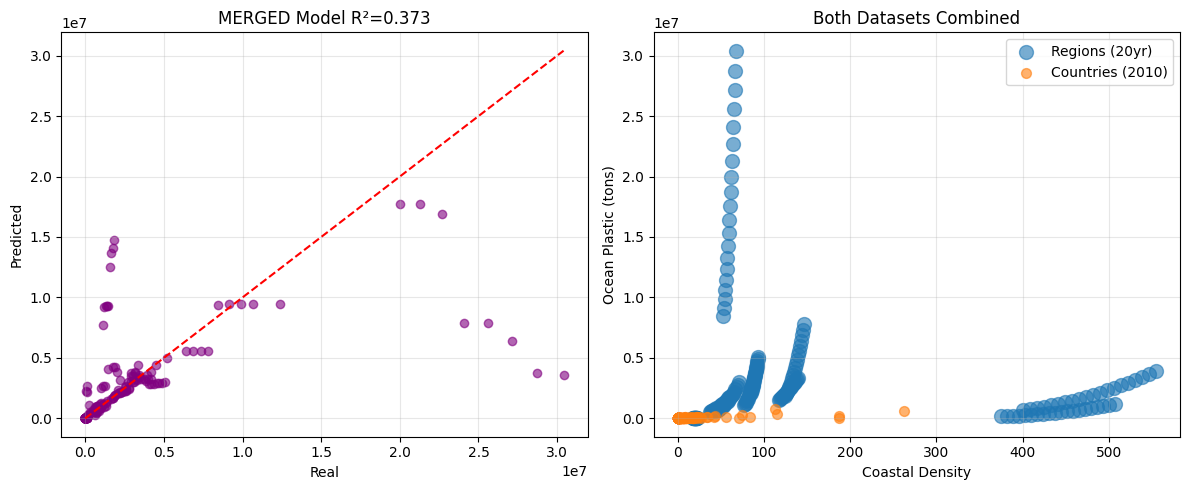


🏢 Business Predictions:
Mumbai: 2,440,114 tons/year
Singapore: 3,423,447 tons/year


c:\Users\Dhanyashree\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Dhanyashree\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
c:\Users\Dhanyashree\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Rural Africa: 25,975 tons/year


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Plot 1: Combined model performance
plt.subplot(1,2,1)
plt.scatter(y_test, y_pred, alpha=0.6, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'MERGED Model R²={r2_score(y_test, y_pred):.3f}')
plt.xlabel('Real'); plt.ylabel('Predicted')
plt.grid(True, alpha=0.3)

# Plot 2: Dataset sources
plt.subplot(1,2,2)
plt.scatter(df1_clean['Density'], df1_clean['Target_MT'], alpha=0.6, label='Regions (20yr)', s=100)
plt.scatter(df2_clean['Density'], df2_clean['Target_MT'], alpha=0.6, label='Countries (2010)', s=50)
plt.xlabel('Coastal Density'); plt.ylabel('Ocean Plastic (tons)')
plt.title('Both Datasets Combined')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Business predictions
print("\n Business Predictions:")
tests = [['Mumbai', 5000, 0.4], ['Singapore', 8000, 0.05], ['Rural Africa', 20, 0.85]]
for name, density, mwi in tests:
    pred = model.predict([[density, mwi]])[0]
    print(f"{name}: {pred:,.0f} tons/year")
